# Lab 4: Model-Based Offline Optimization

## Autor: **Michał Kowalczyk**

In this lab, we explore **Model-Based Offline Optimization (MBO)**, a method to optimize black-box functions using only a pre-collected dataset, without additional function evaluations. We'll use two functions from the **Black-Box Optimization Benchmarking (BBOB)** suite:
- **f1** [Sphere Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=5): A simple, unimodal function with a global minimum at (0, 0).
- **f22** [Gallagher's Gaussian 21-hi Peaks Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=110): A complex, multimodal function with many local optima.

Visualizations of these problems are available [here](https://coco-platform.org/testsuites/bbob/viz.html?col=3&dim=2&fun=1&ins=1&typ=all).

### Objectives
1. **Dataset:** Use pre-collected datasets (100k samples each) for f1 and f22, generated via **Latin Hypercube Sampling (LHS)** [learn more about LHS here](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
2. **Surrogate Model:** Train a Multi-Layer Perceptron (MLP) to approximate these functions.
3. **Visualization:** Compare the MLP's predictions to the true functions using contour and scatter plots.
4. **Optimization:** Implement gradient-based optimization on the MLP to find optimal points.
5. **Experiments:** Investigate how training dataset size and model complexity affect performance.

### Key Concepts
- **Offline Optimization:** No new evaluations of the true function are allowed; we rely solely on the dataset.
- **Surrogate Model:** The MLP acts as a cheap, differentiable proxy for the expensive black-box function.
- **Gradient-Based Optimization:** Use the MLP's gradients to find optimal designs efficiently.

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

In [3]:
device

device(type='cuda')

### 1. Data Preparation

We start by loading and splitting the dataset into training, validation, and test sets.

In [10]:
def prepare_dataloaders(
    file_path: str,
    batch_size: int = 256,
    train_perc: float = 0.6,
    val_perc: float = 0.2,
    train_size: int = None,
    test_size: int = None,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train, validation and test dataloaders.

    Args:
        file_path: Path to CSV data file
        batch_size: Batch size for dataloaders
        train_perc: Percentage of data for training
        val_perc: Percentage of data for validation
    """
    # Load data
    data_df = pd.read_csv(file_path)
    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    # Split data
    num_samples = len(X)
    indices = np.random.permutation(num_samples)

    if train_size is not None or test_size is not None:
        if train_size is None or test_size is None:
            raise ValueError("Both train_size and test_size must be provided if not using percentages for splitting.")
        
        val_size = num_samples - train_size - test_size
        
    else:
        train_size = int(train_perc * num_samples)
        val_size = int(val_perc * num_samples)

    # Create datasets
    train_dataset = TensorDataset(X[indices[:train_size]], y[indices[:train_size]])
    val_dataset = TensorDataset(
        X[indices[train_size : train_size + val_size]],
        y[indices[train_size : train_size + val_size]],
    )
    test_dataset = TensorDataset(
        X[indices[train_size + val_size :]], y[indices[train_size + val_size :]]
    )

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader, test_dataloader

# Example usage (replace with your file path)
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.3, val_perc=0.4
)

### 2. Define the MLP Model

The MLP will serve as our surrogate model to approximate the black-box function.

In [5]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        """
        Multi-Layer Perceptron (MLP) for function approximation.

        Args:
            input_dim (int): Number of input features (e.g., 2 for x1, x2).
            hidden_dim (int): Number of neurons in each hidden layer.
            n_layers (int): Total number of layers (input + hidden + output).
        """
        super(MLP, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer -> 1 output neuron (regression, single-objective problem)
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

### 3. Training the Model

We train the MLP using the Adam optimizer and Mean Squared Error (MSE) loss.

In [6]:
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    val_loss = val_loss / len(val_dataloader.dataset)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
        )

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss = test_loss / len(test_dataloader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 10/100, Train Loss: 595.6701, Val Loss: 536.3131
Epoch 20/100, Train Loss: 299.7637, Val Loss: 295.9050
Epoch 30/100, Train Loss: 231.8813, Val Loss: 231.2250
Epoch 40/100, Train Loss: 189.4114, Val Loss: 188.7086
Epoch 50/100, Train Loss: 169.3041, Val Loss: 165.5492
Epoch 60/100, Train Loss: 150.5342, Val Loss: 178.9977
Epoch 70/100, Train Loss: 135.3623, Val Loss: 133.2038
Epoch 80/100, Train Loss: 126.6214, Val Loss: 126.3915
Epoch 90/100, Train Loss: 118.0879, Val Loss: 126.4117
Epoch 100/100, Train Loss: 112.1000, Val Loss: 118.6928
Test Loss: 118.2916


### 4. Visualization

Let's visualize how well the MLP approximates the true function.

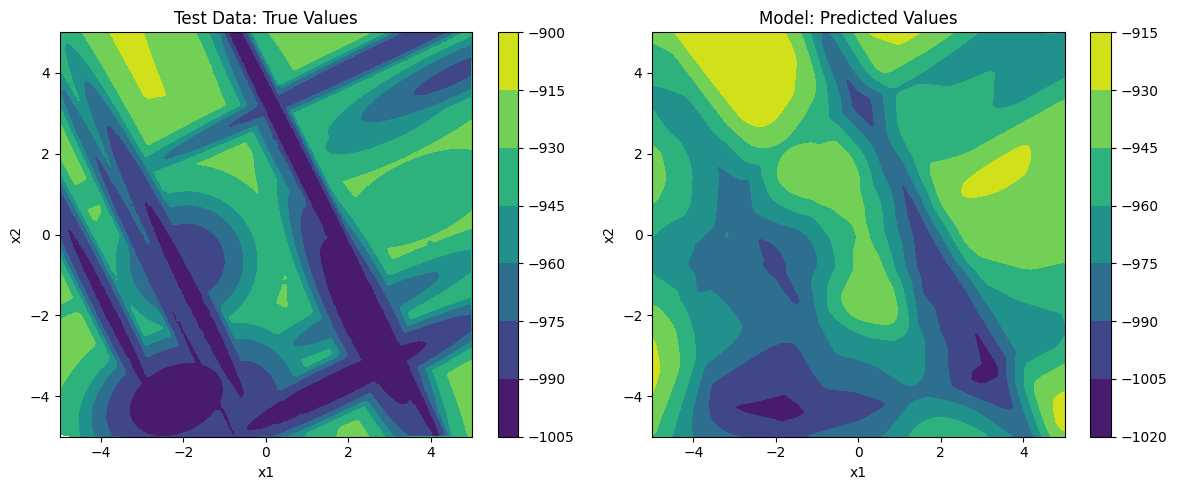

In [7]:
def plot_contour_comparison(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(
        test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1)
    )
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    plt.tight_layout()
    plt.show()

plot_contour_comparison(model, test_dataloader, device)

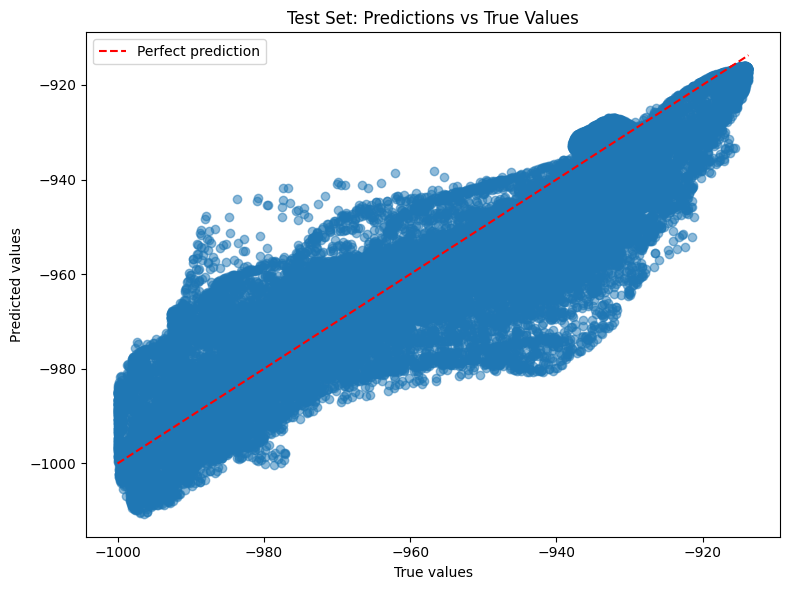

In [8]:
def plot_prediction_scatter(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_targets_list = []
    test_preds_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs)

        test_targets_list.append(targets.cpu().numpy())
        test_preds_list.append(outputs.cpu().numpy())

    test_targets = np.concatenate(test_targets_list)
    test_preds = np.concatenate(test_preds_list).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(test_targets, test_preds, alpha=0.5)
    ax.plot(
        [test_targets.min(), test_targets.max()],
        [test_targets.min(), test_targets.max()],
        "r--",
        label="Perfect prediction",
    )
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title("Test Set: Predictions vs True Values")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_prediction_scatter(model, test_dataloader, device)

### 5. Gradient-Based Optimization

Now, we optimize the trained MLP to find the input that minimizes its output (our surrogate's prediction).

In [18]:
def optimize_model(
    model: nn.Module, num_steps: int = 1000
) -> tuple[torch.Tensor, float]:
    """
    Perform gradient-based optimization on the MLP.

    Args:
        model (nn.Module): Trained MLP model.
        num_steps (int): Number of optimization steps.

    Returns:
        tuple: (best_x, best_y) - Optimal input and its predicted output.
    """
    model.eval()
    # Select random starting point in [-5, 5]^2
    x = torch.rand(1, 2, device=device) * 10 - 5
    x.requires_grad_(True)

    optimizer = torch.optim.Adam([x], lr=0.001) # TODO: select optimizer

    best_x = x.detach().clone()
    best_y = float("inf")

    for _ in range(num_steps):
        optimizer.zero_grad()
        # Predict output (our output - result of the model is the function we want to minimize)
        y_pred = model(x)
        # Compute gradients (gradients of our model)
        loss = y_pred.mean()
        loss.backward()
        # Update x
        optimizer.step()
        # Enforce domain constraints [-5, 5]
        with torch.no_grad():
            x.clamp_(-5, 5)

        current_y = y_pred.item()
        if current_y < best_y:
            best_y = current_y
            best_x = x.detach().clone()

    return best_x, best_y

## Funkcje pomocnicze

In [15]:
def train_model(train_dataloader, val_dataloader, num_epochs=100):
    model = MLP().to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        for inputs, targets in train_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)

        train_loss = train_loss / len(train_dataloader.dataset)
        train_losses.append(train_loss)
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_dataloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss = val_loss / len(val_dataloader.dataset)
        val_losses.append(val_loss)
        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
            )

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for inputs, targets in test_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)

    test_loss = test_loss / len(test_dataloader.dataset)
    print(f"Test Loss: {test_loss:.4f}")

    return model

In [19]:
def evaluate_model(model, test_loader):
    criterion = nn.MSELoss()

    test_loss = 0.0
    model.eval()
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            test_loss += criterion(model(x), y).item() * x.size(0)

    test_loss /= len(test_loader.dataset)

    best_x, best_y = optimize_model(model, num_steps=500)

    return test_loss, best_x, best_y

### Exercise 1: Impact of Dataset Size
- **Task:** Train the MLP with different training set sizes (e.g., 100, 1000, 5000, 10000, 50000).
- **Instructions:**
  1. Modify the `train_perc` parameter in `prepare_dataloaders` to achieve these different dataset sizes (keep the test set size fixed at approximately 30,000 samples).
  2. Train the model for each dataset size and generate corresponding contour plots.
  3. Analyze how the MLP's ability to capture the underlying function structure (particularly the multimodal nature of f22) improves with increasing data volume.
  4. Select and justify a single quantitative metric that effectively captures the model’s predictive quality in this context. Use this metric to evaluate model performance across different training set sizes. Present the results as a plot to visualize how model quality scales with data availability.

### Exercise 2: Optimization Robustness
- **Task:** Implement the `optimize_model` function to find inputs that minimize the model's output.
- **Instructions:**
  1. Execute the optimization process multiple times (e.g. 10 for each dataset) with different random starting points and record the best surrogate values.
  2. Create a histogram of the best `y` values across all optimization runs to visualize the distribution of results.
  3. Generate a contour plot showing the locations of the solutions found. Analyze the consistency of these solutions.
  4. Use `cocoex` to evaluate the true objective function at the solution points. Compare these values against the surrogate’s predicted values.

## Ćwiczenie 1: badanie wpływu rozmiaru zbioru danych


Training with 100 samples
Epoch 10/100, Train Loss: 919866.7500, Val Loss: 905438.5805
Epoch 20/100, Train Loss: 895346.8750, Val Loss: 879314.7275
Epoch 30/100, Train Loss: 857158.3750, Val Loss: 839035.5084
Epoch 40/100, Train Loss: 802004.3125, Val Loss: 781381.0688
Epoch 50/100, Train Loss: 727895.8750, Val Loss: 704644.5949
Epoch 60/100, Train Loss: 635127.0625, Val Loss: 609573.1217
Epoch 70/100, Train Loss: 527178.3125, Val Loss: 500273.7991
Epoch 80/100, Train Loss: 411338.3125, Val Loss: 384806.8090
Epoch 90/100, Train Loss: 298583.3125, Val Loss: 274870.8883
Epoch 100/100, Train Loss: 201915.8906, Val Loss: 183763.0081
Test Loss: 182352.5337
Test MSE: 181128.3036
Surrogate optimum value: -362.9687


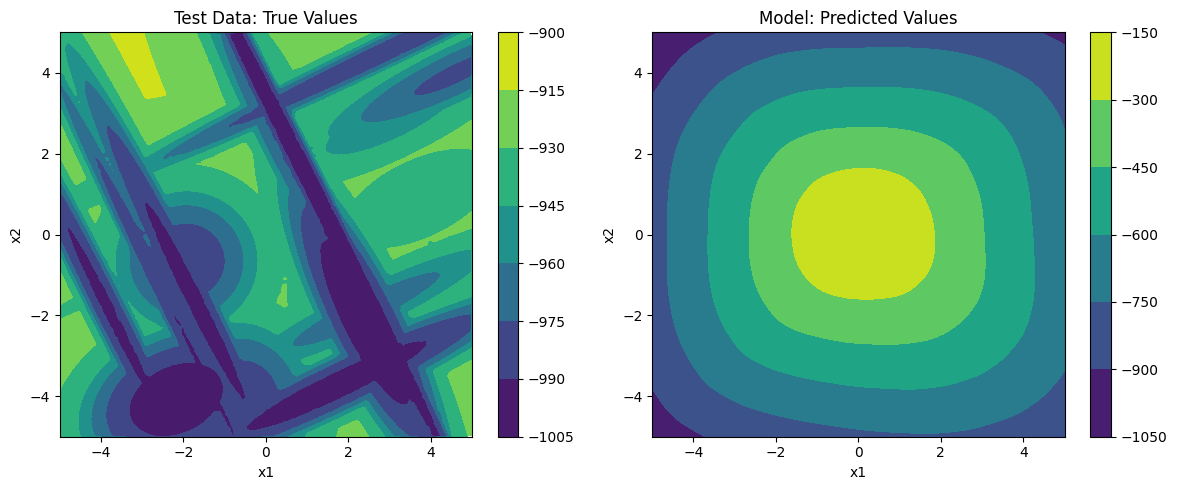


Training with 1000 samples
Epoch 10/100, Train Loss: 797820.2030, Val Loss: 780461.8748
Epoch 20/100, Train Loss: 426140.8975, Val Loss: 393513.5582
Epoch 30/100, Train Loss: 112980.1232, Val Loss: 98519.0591
Epoch 40/100, Train Loss: 87170.4116, Val Loss: 78982.4997
Epoch 50/100, Train Loss: 82098.1358, Val Loss: 74726.1411
Epoch 60/100, Train Loss: 77053.8087, Val Loss: 70178.7057
Epoch 70/100, Train Loss: 71631.3817, Val Loss: 65284.9558
Epoch 80/100, Train Loss: 65825.9506, Val Loss: 60056.1018
Epoch 90/100, Train Loss: 59767.9677, Val Loss: 54563.7064
Epoch 100/100, Train Loss: 53388.9414, Val Loss: 48812.9727
Test Loss: 48991.9853
Test MSE: 49096.5865
Surrogate optimum value: -1137.5898


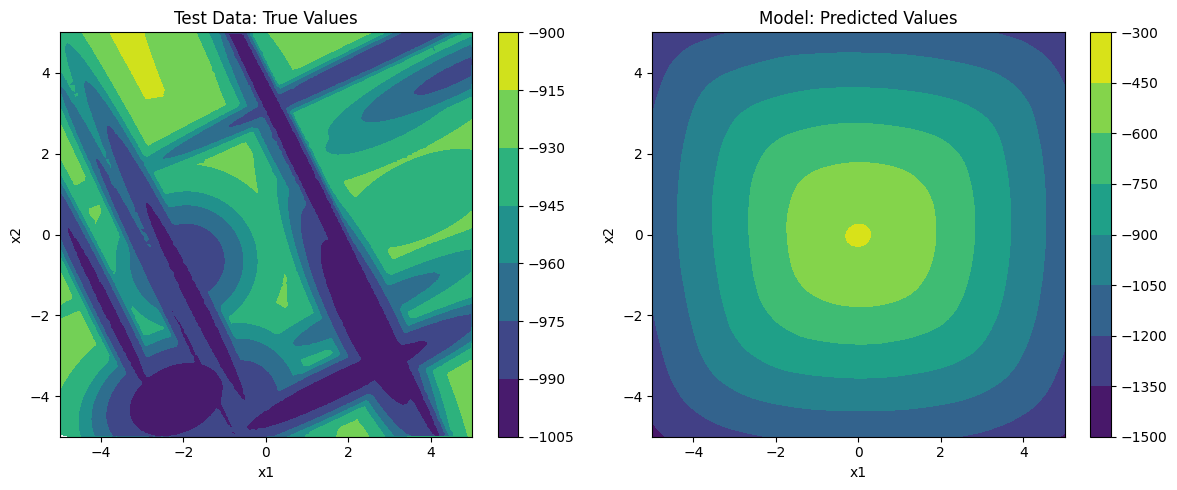


Training with 5000 samples
Epoch 10/100, Train Loss: 77634.7454, Val Loss: 77834.6979
Epoch 20/100, Train Loss: 53545.8945, Val Loss: 53033.8706
Epoch 30/100, Train Loss: 26197.5381, Val Loss: 25179.6176
Epoch 40/100, Train Loss: 6424.1332, Val Loss: 5955.9393
Epoch 50/100, Train Loss: 1002.9651, Val Loss: 951.6899
Epoch 60/100, Train Loss: 523.5208, Val Loss: 527.1053
Epoch 70/100, Train Loss: 478.1678, Val Loss: 481.8104
Epoch 80/100, Train Loss: 453.9763, Val Loss: 457.6405
Epoch 90/100, Train Loss: 433.5287, Val Loss: 436.8621
Epoch 100/100, Train Loss: 414.5693, Val Loss: 416.2141
Test Loss: 415.6604
Test MSE: 410.0586
Surrogate optimum value: -954.9173


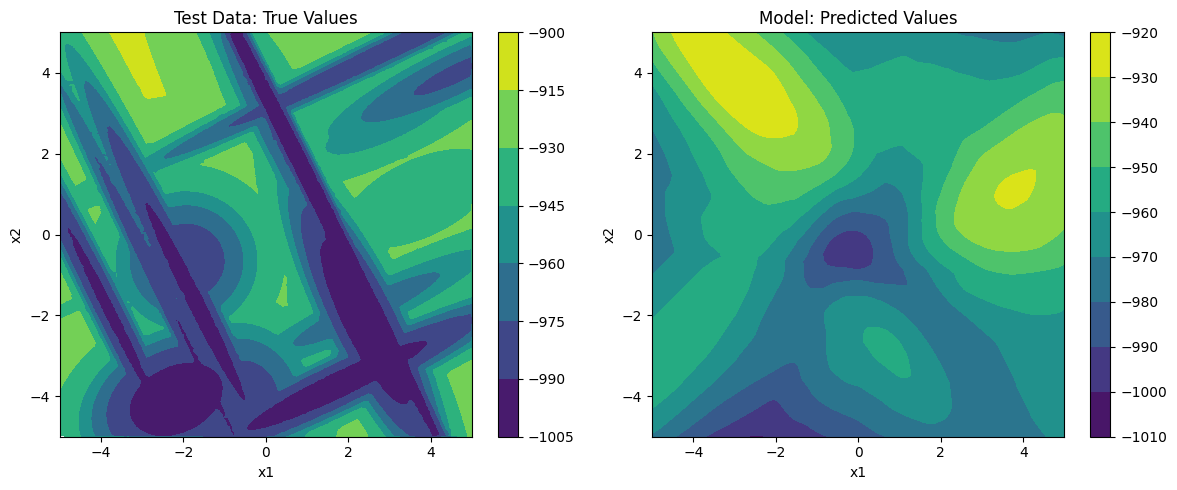


Training with 10000 samples
Epoch 10/100, Train Loss: 53677.8682, Val Loss: 50878.6833
Epoch 20/100, Train Loss: 4574.1237, Val Loss: 3590.0909
Epoch 30/100, Train Loss: 452.6220, Val Loss: 448.5352
Epoch 40/100, Train Loss: 363.8490, Val Loss: 362.4981
Epoch 50/100, Train Loss: 330.7921, Val Loss: 327.0668
Epoch 60/100, Train Loss: 311.5062, Val Loss: 310.2633
Epoch 70/100, Train Loss: 293.1422, Val Loss: 287.3820
Epoch 80/100, Train Loss: 276.2355, Val Loss: 270.3435
Epoch 90/100, Train Loss: 260.7434, Val Loss: 251.9458
Epoch 100/100, Train Loss: 244.8312, Val Loss: 236.3589
Test Loss: 238.4911
Test MSE: 236.7408
Surrogate optimum value: -988.4214


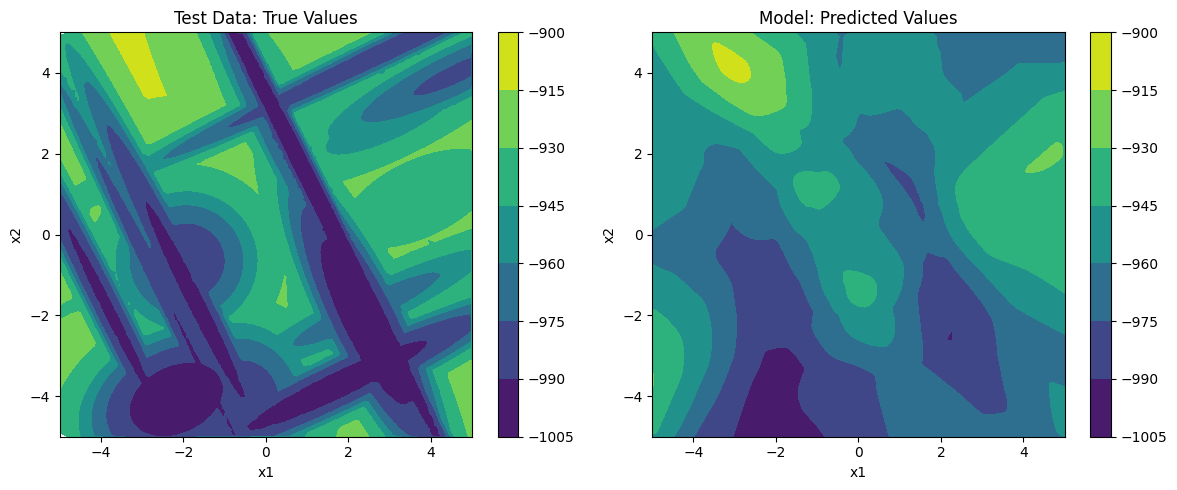


Training with 50000 samples
Epoch 10/100, Train Loss: 367.9750, Val Loss: 355.3081
Epoch 20/100, Train Loss: 226.8479, Val Loss: 224.9487
Epoch 30/100, Train Loss: 189.2789, Val Loss: 191.0985
Epoch 40/100, Train Loss: 172.7306, Val Loss: 183.9420
Epoch 50/100, Train Loss: 160.0021, Val Loss: 166.7989
Epoch 60/100, Train Loss: 151.6690, Val Loss: 151.9711
Epoch 70/100, Train Loss: 142.5573, Val Loss: 147.6136
Epoch 80/100, Train Loss: 139.1752, Val Loss: 138.7336
Epoch 90/100, Train Loss: 136.5816, Val Loss: 132.0356
Epoch 100/100, Train Loss: 133.2389, Val Loss: 133.3721
Test Loss: 134.1102
Test MSE: 133.5182
Surrogate optimum value: -992.0527


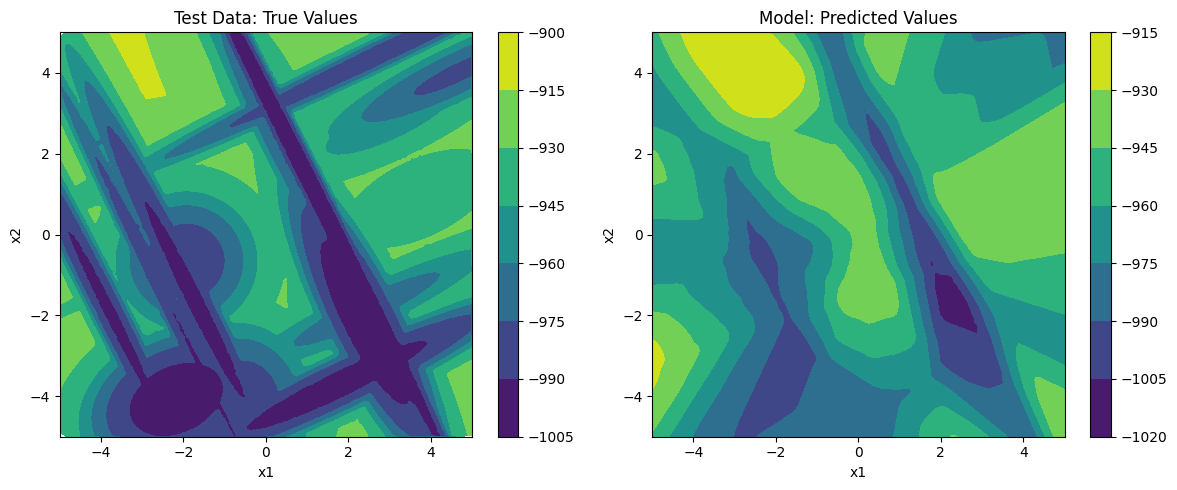

In [20]:
train_sizes = [100, 1000, 5000, 10000, 50000]

results = []

for n in train_sizes:
    print(f"\nTraining with {n} samples")

    train_loader, val_loader, test_loader = prepare_dataloaders(
        file_path="./bbob_f022_i01_d02_samples.csv",
        train_size=n,
        test_size=30000
    )

    model = train_model(train_loader, val_loader)

    test_mse, best_x, best_y = evaluate_model(model, test_loader)

    print(f"Test MSE: {test_mse:.4f}")
    print(f"Surrogate optimum value: {best_y:.4f}")

    plot_contour_comparison(model, test_loader, device)

    results.append((n, test_mse, best_y))

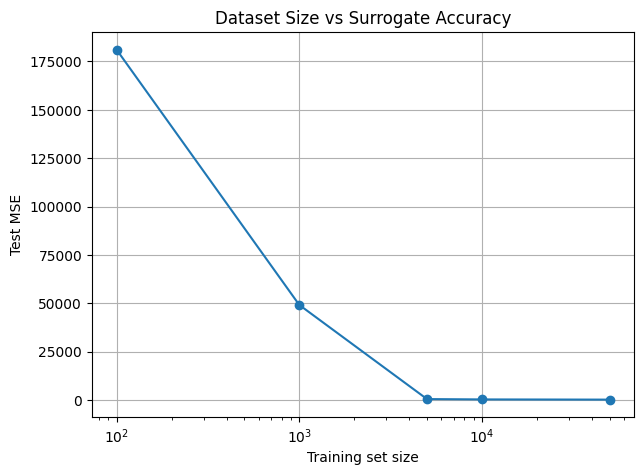

In [21]:
train_sizes = [r[0] for r in results]
test_mse = [r[1] for r in results]
opt_vals = [r[2] for r in results]

plt.figure(figsize=(7,5))
plt.plot(train_sizes, test_mse, marker='o')
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("Test MSE")
plt.title("Dataset Size vs Surrogate Accuracy")
plt.grid()
plt.show()

## Ćwiczenie 2: badanie optymalizacji

In [22]:
def run_multiple_optimizations(model, n_runs=10):
    best_xs = []
    surrogate_vals = []

    for i in range(n_runs):
        best_x, best_y = optimize_model(model, num_steps=500)

        best_xs.append(best_x.cpu().numpy())
        surrogate_vals.append(best_y)

    return np.array(best_xs), np.array(surrogate_vals)

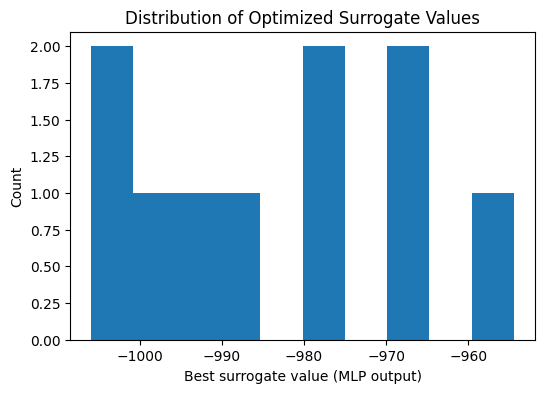

In [23]:
best_xs, surrogate_vals = run_multiple_optimizations(model, n_runs=10)

plt.figure(figsize=(6,4))
plt.hist(surrogate_vals, bins=10)
plt.xlabel("Best surrogate value (MLP output)")
plt.ylabel("Count")
plt.title("Distribution of Optimized Surrogate Values")
plt.show()

In [24]:
def plot_solution_locations(model, test_loader, best_xs):
    test_inputs = []
    for x, _ in test_loader:
        test_inputs.append(x.numpy())
    test_inputs = np.vstack(test_inputs)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()

    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid = np.column_stack([X1.ravel(), X2.ravel()])
    grid_t = torch.tensor(grid, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        Z = model(grid_t).cpu().numpy().reshape(X1.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(X1, X2, Z, levels=30)
    plt.colorbar(label="MLP value")

    best_xs = np.array(best_xs).squeeze()
    plt.scatter(best_xs[:,0], best_xs[:,1], c="red", label="optima found")

    plt.legend()
    plt.title("Optimized Points on Surrogate Landscape")
    plt.show()

In [46]:
from cocoex import Suite

def evaluate_true_function(best_xs, function_id=22):
    function_id = 22

    suite = Suite(
        "bbob",
        "",
        f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
    )

    true_vals = []

    for function in suite:
        print(function.info)
        print("Function value at (0, 0):", function(np.array([0, 0])))

        for x in best_xs:
            x = np.asarray(x, dtype=np.float64).reshape(2,)
            val = function(x)
            true_vals.append(val)

    return np.array(true_vals)

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844


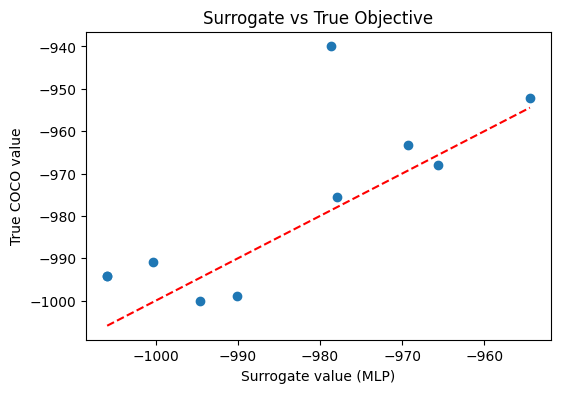

In [47]:
true_vals = evaluate_true_function(best_xs, function_id=22)

plt.figure(figsize=(6,4))
plt.scatter(surrogate_vals, true_vals)
plt.xlabel("Surrogate value (MLP)")
plt.ylabel("True COCO value")
plt.title("Surrogate vs True Objective")
plt.plot(
    [min(surrogate_vals), max(surrogate_vals)],
    [min(surrogate_vals), max(surrogate_vals)],
    "r--"
)
plt.show()

### Accessing Original COCO Benchmark Problems

The code below installs and imports the necessary packages to access the original COCO benchmark problems (f1 and f22).
This will allow us to compare our model's predictions with the true functions and evaluate optimization performance.

In [ ]:
! pip install coco-experiment cocopp

In [36]:
from cocoex import Suite

function_id = 22  # Switch between 1 and 22 to change the function

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
for function in suite:
    print(function.info)
    print("Function value at (0, 0):", function(np.array([0, 0])))

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844
